# CUB-200 · Baby Dragon Hatchling · Hebbian explainability bundle

Trains a bird classifier on **CUB-200-2011** with the `hatchvision` framework,
records **Hebbian co-activation** of the BDH sparse-neuron space during training,
clusters the neurons into concepts, **grounds each concept in CUB's 312 visual
attributes** ("wing color: yellow", "bill shape: hooked", ...), and exports the
complete **in-browser inference bundle** for the web app:

- `graph.json` — the Hebbian concept graph (IVGraph)
- `model.onnx` — the classifier with neuron-activation outputs
- `manifest.json` — preprocessing constants + node mapping

**How to run this on Kaggle**
1. *Add Input* → search for the dataset **`wenewone/cub2002011`** (or any mirror of
   the official `CUB_200_2011.tgz`) and attach it. If the notebook has internet
   access it can also download the archive itself (~1.1 GB).
2. *Settings* → **Accelerator: GPU** (T4/P100), **Internet: On** (needed to clone the
   repo and fetch pretrained weights).
3. *Run All* (~30–45 min on a T4 with the default config).
4. Download **`/kaggle/working/bundle.zip`**, unzip its contents into the repo's
   `webapp/` directory, and redeploy — the site then classifies bird photos.

**The universal-tool promise:** nothing below is CUB-specific except the string
`"cub200"` and the attribute display. To rerun this experiment on another dataset,
register a loader for it and change `DATASET` in the config cell — the rest of the
pipeline (training, Hebbian memory, concepts, grounding when attributes exist,
export) is identical.

In [1]:
# Install hatchvision from the repo
BRANCH = "claude/baby-dragon-classifier-tool-pwtgoj"   # or "main" once merged
!git clone --depth 1 -b {BRANCH} https://github.com/LarsGroep/DragonHatchling.git
%cd DragonHatchling
!pip install -q onnx onnxruntime onnxconverter-common

import sys, torch
sys.path.insert(0, ".")
import hatchvision
print("hatchvision", hatchvision.__version__, "· torch", torch.__version__,
      "· cuda:", torch.cuda.is_available())

Cloning into 'DragonHatchling'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 62 (delta 2), reused 43 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 2.98 MiB | 10.71 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/kaggle/working/DragonHatchling
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 7.2 MB/s eta 0:00:00
hatchvision 0.1.0 · torch 2.10.0+cu128 · cuda: True


In [2]:
# ---------------------------- configuration ----------------------------
DATASET      = "cub200"    # any registered loader: swap dataset here, retrain, done
BACKBONE     = "hybrid"    # "hybrid" (pretrained encoder + BDH neurons)  or  "bdh" (pure, from scratch)
EPOCHS       = 12
BATCH_SIZE   = 64
LR           = 1e-3
MAX_UNITS    = 512         # Hebbian tracked neurons (subsampled from neuron_dim)
N_CONCEPTS   = 24
PROBE_IMAGES = 768         # val images used for exemplars + attribute grounding

# per-backbone architecture knobs
BACKBONE_KWARGS = {
    "hybrid": dict(encoder="resnet50", pretrained=True, freeze_encoder=True,
                   neuron_dim=4096),
    # pure BDH from scratch: keep the token count manageable at 128 px
    "bdh":    dict(patch_size=16, dim=256, neuron_dim=2048, depth=6,
                   share_weights=True),
}[BACKBONE]
IMAGE_SIZE = 224 if BACKBONE == "hybrid" else 128
if BACKBONE == "bdh":
    EPOCHS, LR = max(EPOCHS, 30), 3e-4   # from-scratch training needs longer

In [3]:
# ------------------------- locate / fetch CUB-200 -------------------------
from pathlib import Path

def find_cub_root():
    hits = list(Path("/kaggle/input").glob("**/images.txt"))
    for h in hits:
        if (h.parent / "image_class_labels.txt").exists():
            return h.parent
    return None

root = find_cub_root()
if root is None:
    print("No attached CUB dataset found — downloading (~1.1 GB)…")
    from hatchvision.data.cub import DOWNLOAD_URL
    from torchvision.datasets.utils import download_and_extract_archive
    download_and_extract_archive(DOWNLOAD_URL, "/kaggle/working/cub")
    root = find_cub_root() or Path("/kaggle/working/cub")
print("CUB root:", root)

No attached CUB dataset found — downloading (~1.1 GB)…


100%|██████████| 1.15G/1.15G [00:47<00:00, 24.4MB/s]


CUB root: /kaggle/working/cub


In [4]:
from hatchvision import (HebbianFeatureMemory, TrainConfig, Trainer,
                         build_loader, create_model)

data = build_loader(DATASET, root=str(root), image_size=IMAGE_SIZE)
train_loader, val_loader = data.dataloaders(batch_size=BATCH_SIZE, num_workers=2)
print(data.spec.num_classes, "classes ·",
      len(train_loader.dataset), "train /", len(val_loader.dataset), "val")

model = create_model(BACKBONE, data.spec, **BACKBONE_KWARGS)
memory = HebbianFeatureMemory(model, num_classes=data.spec.num_classes,
                              max_units=MAX_UNITS)
print("Hebbian memory observes:", list(model.hebbian_layers()))
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable parameters: {n_train/1e6:.1f} M")

200 classes · 5994 train / 5794 val
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Hebbian memory observes: ['neurons']
trainable parameters: 17.2 M


In [5]:
trainer = Trainer(model, TrainConfig(epochs=EPOCHS, lr=LR, log_every=25), memory)
history = trainer.fit(train_loader, val_loader)
print(f"final val accuracy: {history['val_acc'][-1]:.3f}")

epoch 1/12
  step    0/94  loss 5.3273  acc 0.000
  step   25/94  loss 3.2384  acc 0.110
  step   50/94  loss 2.7957  acc 0.190
  step   75/94  loss 2.2877  acc 0.250
  train loss 3.0367 acc 0.279 | val loss 1.9385 acc 0.467
epoch 2/12
  step    0/94  loss 1.7451  acc 0.453
  step   25/94  loss 1.3283  acc 0.560
  step   50/94  loss 1.3856  acc 0.564
  step   75/94  loss 1.1405  acc 0.575
  train loss 1.4452 acc 0.584 | val loss 1.4673 acc 0.586
epoch 3/12
  step    0/94  loss 1.0368  acc 0.672
  step   25/94  loss 0.9195  acc 0.705
  step   50/94  loss 0.8966  acc 0.707
  step   75/94  loss 0.9399  acc 0.712
  train loss 0.9641 acc 0.708 | val loss 1.4444 acc 0.609
epoch 4/12
  step    0/94  loss 0.5727  acc 0.812
  step   25/94  loss 0.4633  acc 0.802
  step   50/94  loss 0.8610  acc 0.800
  step   75/94  loss 0.7581  acc 0.796
  train loss 0.6831 acc 0.793 | val loss 1.4660 acc 0.633
epoch 5/12
  step    0/94  loss 0.3327  acc 0.922
  step   25/94  loss 0.4775  acc 0.853
  step   50

## Concepts: cluster the Hebbian co-activation, ground in attributes

Units that fired together during training are clustered into concepts. Each
concept is then correlated with CUB's per-image attribute annotations over a
probe set, so it gets a name like *"wing color: yellow · bill shape: hooked"*
instead of *"concept 7"*. Datasets without attributes skip this step
automatically and keep class-affinity labels.

In [6]:
from hatchvision.explain import cluster_concepts, find_exemplars, ground_concepts

layer = memory.layer_names[-1]
concepts = cluster_concepts(memory, layer, data.spec.class_names,
                            n_concepts=N_CONCEPTS)
probe = data.probe_batch(PROBE_IMAGES)
find_exemplars(concepts, memory, model, probe)

attr_names = data.attribute_names()
attr_matrix = data.probe_attributes(probe.shape[0])
if attr_names and attr_matrix is not None:
    ground_concepts(concepts, memory, model, probe, attr_matrix, attr_names)
    print(f"grounded {sum(1 for c in concepts if c.attributes)}/{len(concepts)} concepts")

for c in concepts[:12]:
    attrs = " · ".join(list(c.attributes)[:3]) if c.attributes else "—"
    top_cls = max(c.class_affinity, key=c.class_affinity.get) if c.class_affinity else "—"
    print(f"[{c.concept_id:>2}] {len(c.units):>3} units  coh {c.coherence:.2f}  "
          f"{attrs:<60}  top class: {top_cls}")

grounded 24/24 concepts
[ 9]   4 units  coh 0.27  primary color: pink · breast color: orange · upperparts color: blue  top class: Yellow bellied Flycatcher
[ 3]   5 units  coh 0.19  under tail color: pink · crown color: pink · bill color: rufous  top class: Horned Lark
[16]   3 units  coh 0.26  eye color: red · under tail color: pink · crown color: pink   top class: Bronzed Cowbird
[20]   2 units  coh 0.24  upperparts color: rufous · shape: owl-like · wing color: rufous  top class: Winter Wren
[11]   2 units  coh 0.25  leg color: rufous · crown color: orange · forehead color: white  top class: Red eyed Vireo
[22]   2 units  coh 0.31  forehead color: yellow · breast color: yellow · underparts color: yellow  top class: Western Meadowlark
[ 8]   5 units  coh 0.17  forehead color: yellow · crown color: yellow · belly color: black  top class: Loggerhead Shrike
[ 6]   4 units  coh 0.21  leg color: orange · shape: owl-like · upper tail color: rufous  top class: Black and white Warbler
[ 5]   

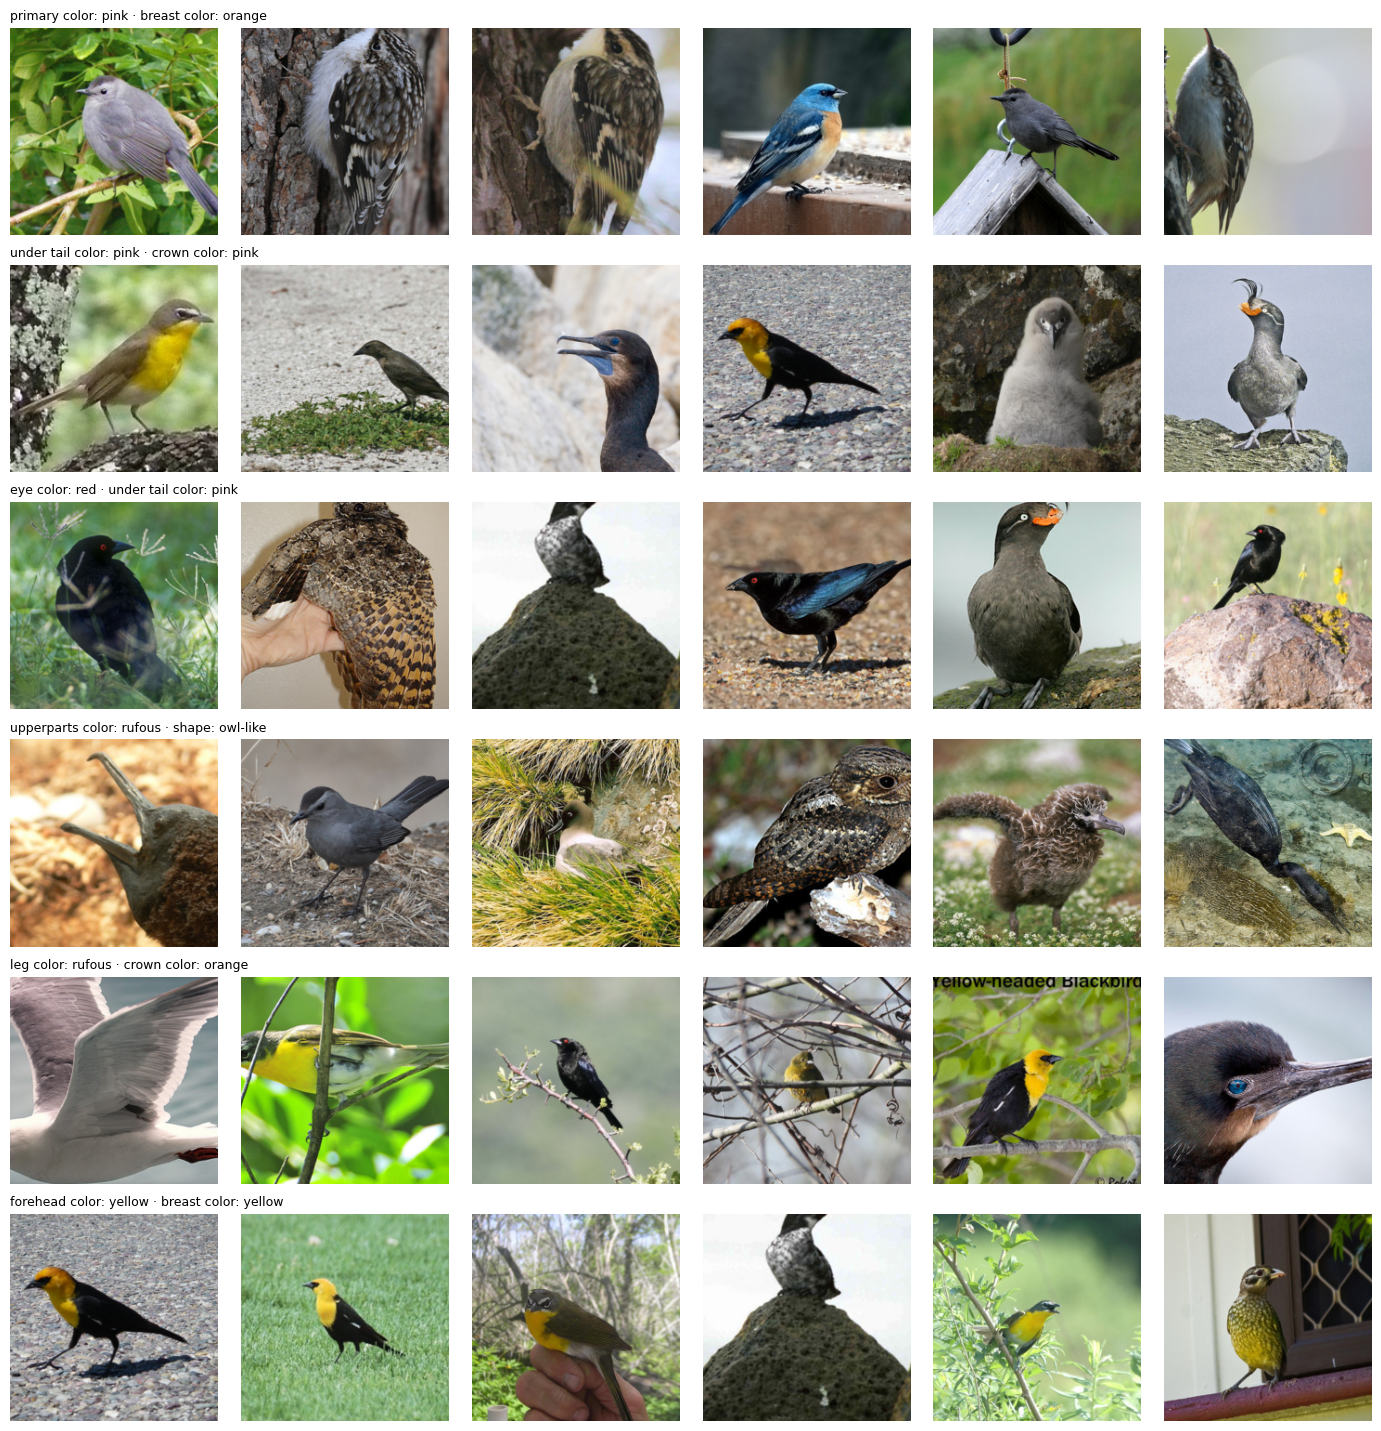

In [7]:
# visual check: exemplar images for the strongest concepts
import matplotlib.pyplot as plt
from hatchvision.explain import denormalize

mean, std = data.spec.normalization()
show = [c for c in concepts if c.exemplars][:6]
fig, axes = plt.subplots(len(show), 6, figsize=(14, 2.4 * len(show)))
for row, c in zip(axes, show):
    for ax, idx in zip(row, c.exemplars):
        img = denormalize(probe[idx:idx + 1], mean, std)[0]
        ax.imshow(img.permute(1, 2, 0))
        ax.axis("off")
    row[0].set_title(c.label, loc="left", fontsize=9)
plt.tight_layout(); plt.show()

## Export the web-app bundle

In [8]:
from hatchvision.export import export_ivgraph, export_onnx_bundle, export_explain_pack

OUT = Path("/kaggle/working/bundle")
export_ivgraph(memory, concepts, layer, data.spec.class_names, OUT / "graph.json",
               meta={"dataset": data.spec.name, "backbone": BACKBONE,
                     "val_acc": round(history["val_acc"][-1], 4)})
# demo explain pack: per-class Hebbian activation regions + the unit->class
# SHAP influence matrix (exact for the hybrid/bdh linear neuron readout) --
# powers the web app's class-region picker, SHAP bars and demo tour.
# Run while the model is still on the GPU (needs forward+backward passes).
export_explain_pack(memory, layer, data.spec.class_names, OUT / "explain.json",
                    model=model, background=probe[:64])
# fp16 halves the in-browser download; predictions are unchanged
export_onnx_bundle(model.cpu(), memory, data.spec, OUT, fp16=True,
                   explain_file="explain.json",
                   extra_meta={"backbone": BACKBONE})
# raw Hebbian statistics: lets scripts/rebuild_graph.py re-cluster and
# re-export the graph later without retraining
torch.save(memory.state_dict(), OUT / "hebbian_state.pt")

import shutil
shutil.make_archive("/kaggle/working/bundle", "zip", OUT)
!ls -la /kaggle/working/bundle /kaggle/working/bundle.zip
print("""
Done. Download bundle.zip (right panel -> Output), unzip its files into the
repo's webapp/ directory (replacing the previous bundle), and redeploy:
    cd webapp && npx vercel deploy --prod

To iterate on concept clustering WITHOUT retraining, keep hebbian_state.pt:
    python scripts/rebuild_graph.py --state hebbian_state.pt \
        --manifest manifest.json --dataset cub200 --root <cub_root> \
        --n-concepts 24 --out graph.json --explain-out explain.json
""")

/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 4.5078055177505405e-10 will be truncated to 1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -1.0238084685587623e-10 will be truncated to -1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 5.760020793665888e-10 will be truncated to 1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -1.330452970016438e-09 will be truncated to -1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:52: UserWarning: the float32 number 3.6974000250378225e-12 will be truncated to 1e-07
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxconverter_common/float16.py:70: UserWarning: the float32 number -2.256588362350

-rw-r--r-- 1 root root 76539196 Jul  3 13:40 /kaggle/working/bundle.zip

/kaggle/working/bundle:
total 81020
drwxr-xr-x 2 root root     4096 Jul  3 13:40 .
drwxr-xr-x 5 root root     4096 Jul  3 13:40 ..
-rw-r--r-- 1 root root    75394 Jul  3 13:40 graph.json
-rw-r--r-- 1 root root  1467931 Jul  3 13:40 hebbian_state.pt
-rw-r--r-- 1 root root     5200 Jul  3 13:40 manifest.json
-rw-r--r-- 1 root root 81396280 Jul  3 13:40 model.onnx

Done. Download bundle.zip (right panel -> Output), unzip its files into the
repo's webapp/ directory (replacing the previous bundle), and redeploy:
    cd webapp && npx vercel deploy --prod

To iterate on concept clustering WITHOUT retraining, keep hebbian_state.pt:
    python scripts/rebuild_graph.py --state hebbian_state.pt         --manifest manifest.json --dataset cub200 --root <cub_root>         --n-concepts 24 --out graph.json



In [9]:
# optional sanity check: ONNX output matches PyTorch
import onnxruntime, numpy as np, torch
sess = onnxruntime.InferenceSession(str(OUT / "model.onnx"))
x = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
model.eval()
with torch.no_grad():
    ref = model(x).numpy()
out = sess.run(None, {"images": x.numpy()})[0]
print("max |onnx - torch| =", float(np.abs(out - ref).max()))

max |onnx - torch| = 0.11002349853515625
